# Projetos de implantação hunter: onde cada um está e o que precisa de ação

Base: exportação do CES (`Ces-Julio_.xlsx`), cruzando as abas Projetos, Hr Adquirida, OS executada, OS planejada e Implantador.

Regras combinadas em 02/10/2026:

- **Hunter** = projeto do tipo implantação ou reimplantação nos departamentos CES Implantação AgriManager e CES Implantação myFarm.
- **Em aberto** = em andamento e suspenso (não iniciado e pendência entram se aparecerem).
- **Hora utilizada** = OS fechada, validada ou acertada (concluída, no sistema antigo). Agenda confirmada que já passou e ficou sem OS fechada aparece à parte.
- **Analista de projeto** = coluna GERENTE. **Consultor responsável** = coluna RESPONSAVEL; quem de fato atendeu vem das OS.

As regras e os cálculos moram em `modelo.py`, o mesmo módulo que gera o painel.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import modelo

pd.set_option("display.max_columns", None)

In [2]:
COR_MYFARM      = "#f08c3c"
COR_AGRIMANAGER = "#1a7f4b"
COR_NEUTRA      = "#94A3B8"
COR_SISTEMA = {"myFarm": COR_MYFARM, "AgriManager": COR_AGRIMANAGER}

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## A planilha foi lida corretamente?
Cada aba tem duas linhas de título antes do cabeçalho; os nomes das colunas vêm como `Tabela[COLUNA]`. Conferindo tamanho, tipos e uma amostra.

In [3]:
bruto = modelo.ler_planilha("Ces-Julio_.xlsx")
pd.DataFrame({aba: df.shape for aba, df in bruto.items() if aba != "atualizado_em"}, index=["linhas", "colunas"]).T

,linhas,colunas
projetos,2936,25
horas,4361,9
os,17957,23
planejada,13159,20
implantador,381,13


In [4]:
print("posição da exportação:", bruto["atualizado_em"])
bruto["projetos"][["COD", "PROJETO", "SISTEMA", "TIPO_PROJETO", "STATUS", "GERENTE", "RESPONSAVEL", "DT_INICIAL", "PREVISTO"]].head()

posição da exportação: 2026-10-01 10:22:08


,COD,PROJETO,SISTEMA,TIPO_PROJETO,STATUS,GERENTE,RESPONSAVEL,DT_INICIAL,PREVISTO
0,10000012,COMDEAGRO - CUIABA/MT,SIAGRI AGRIMANAGER,IMPLANTACAO,CANCELADO,MARCOS PAULO BARBOSA,NaN,2012-09-25,387.00
1,10000014,SEMENTES VITORIA - RIO VERDE/GO,SIAGRI AGRIMANAGER,IMPLANTACAO,CONCLUIDO,MARCOS PAULO BARBOSA,NaN,2012-11-07,122.00
2,10000019,FAZENDA SANTA RITA - VILA RICA/MT,SIAGRI AGRIMANAGER,IMPLANTACAO,CONCLUIDO,MARCOS PAULO BARBOSA,NaN,2013-02-04,139.70
3,10000020,AGROER AVIACAO AGRICOLA - RONDONOPOLIS/MT,SIAGRI AGRIMANAGER,IMPLANTACAO,CONCLUIDO,MARCOS PAULO BARBOSA,NaN,2012-12-12,180.00
4,10000021,AGRO NORTE PESQUISAS E SEMENTES,SIAGRI AGRIMANAGER,MOD.VERTICAL,CONCLUIDO,MARCOS PAULO BARBOSA,NaN,2013-06-14,40.44


In [5]:
bruto["os"][["OS", "COD_PROJETO", "COD_HORA_ADQUIRIDA", "DATA_OS", "CONSULTOR", "HORAS_TRABALHADAS", "ETAPA", "STATUS_OS"]].dtypes.to_frame("tipo")

,tipo
OS,int64
COD_PROJETO,int64
COD_HORA_ADQUIRIDA,float64
DATA_OS,datetime64[us]
CONSULTOR,str
HORAS_TRABALHADAS,float64
ETAPA,str
STATUS_OS,str


**Resultado:** leitura limpa. As datas vieram como data, horas como número e os nomes com acento legíveis. A aba `OS EXECUTADA1` é cópia da `OS_EXECUTADA` sem a coluna de status, então fica de fora.

## As abas se ligam pelas chaves que parecem ligar?
Se uma chave não fecha, o saldo de horas sai errado. Conferindo quanto de cada aba encontra par na outra.

In [6]:
p, h, os_, pl, imp = (bruto[k] for k in ["projetos", "horas", "os", "planejada", "implantador"])
pacote = h[["CODIGO", "PROJETO"]].rename(columns={"PROJETO": "PROJETO_DO_PACOTE"})
hora_do_projeto = os_.dropna(subset=["COD_HORA_ADQUIRIDA"]).merge(pacote, left_on="COD_HORA_ADQUIRIDA", right_on="CODIGO")
pd.DataFrame({
    "ligação": ["Hr Adquirida → Projetos", "OS → Projetos", "OS → Hr Adquirida", "OS planejada → OS", "OS → Implantador",
                "pacote de horas da OS é do mesmo projeto"],
    "% com par": [h.PROJETO.isin(p.COD).mean(), os_.COD_PROJETO.isin(p.COD).mean(), os_.COD_HORA_ADQUIRIDA.dropna().isin(h.CODIGO).mean(),
                  pl.OS.isin(os_.OS).mean(), os_.COD_CONSULTOR.isin(imp.COD_IMPLANTADOR).mean(),
                  (hora_do_projeto.PROJETO_DO_PACOTE == hora_do_projeto.COD_PROJETO).mean()],
}).round(3)

,ligação,% com par
0,Hr Adquirida → Projetos,0.971
1,OS → Projetos,0.969
2,OS → Hr Adquirida,1.000
3,OS planejada → OS,1.000
4,OS → Implantador,1.000
5,pacote de horas da OS é do mesmo projeto,1.000


In [7]:
dup = p[p.COD.duplicated(keep=False)]
print("projetos repetidos:", dup.COD.nunique())
print("colunas que mudam entre as cópias:", [c for c in p.columns if (dup.groupby("COD")[c].nunique(dropna=False) > 1).any()])

projetos repetidos: 322
colunas que mudam entre as cópias: ['COD_GRUPO_ECONOMICO', 'GRUPO_CONOMICO', 'MANUTENCAO_TOTAL_DO_GRUPO']


**Resultado:** as ligações fecham. Toda OS aponta pra um pacote de horas que é do próprio projeto, então dá pra somar horas por projeto sem risco de misturar. Os 3% de horas e OS sem projeto correspondente são de projetos que não vieram na aba Projetos; nenhum pode ser hunter, porque o filtro hunter parte dessa aba.

322 projetos aparecem repetidos, e a diferença está só no grupo econômico e no valor de manutenção do grupo. O modelo fica com uma linha por projeto (a de maior manutenção), senão as horas contariam em dobro.

## Quantos projetos hunter estão em aberto?
Daqui pra frente, tudo vem do `modelo.montar`, que aplica as regras do topo.

In [8]:
m = modelo.montar("Ces-Julio_.xlsx")
ab = m.abertos
print("data de posição:", m.ref.date(), "| projetos hunter (todos os status):", len(m.hunter))
pd.crosstab(ab.SISTEMA_NOME, ab.STATUS, margins=True, margins_name="Total")

data de posição: 2026-10-01 | projetos hunter (todos os status): 478


STATUS,EM ANDAMENTO,SUSPENSO,Total
SISTEMA_NOME,,,
AgriManager,11,6,17
myFarm,62,4,66
Total,73,10,83


In [9]:
pd.crosstab(ab.TIPO_PROJETO, ab.SISTEMA_NOME)

SISTEMA_NOME,AgriManager,myFarm
TIPO_PROJETO,,
IMPLANTACAO,15,64
REIMPLANTACAO,2,2


**Resultado:** a carteira hunter aberta é quatro quintos myFarm. No AgriManager, um terço dos abertos está suspenso, e a pergunta mais adiante é há quanto tempo.

## Quanto das horas adquiridas já foi usado, e quanto sobra?
Horas adquiridas somam todos os pacotes do projeto (contratadas, bonificadas, transferidas). Utilizadas são só as de OS fechada, validada ou acertada.

In [10]:
cols = ["ADQUIRIDAS", "UTILIZADAS", "HORAS_SEM_FECHAR", "HORAS_AGENDADAS", "SALDO", "SALDO_LIVRE"]
horas = ab.groupby("SISTEMA_NOME")[cols].sum()
horas.loc["Total"] = horas.sum()
horas["% usado"] = horas.UTILIZADAS / horas.ADQUIRIDAS
horas.insert(0, "projetos", ab.groupby("SISTEMA_NOME").size().reindex(horas.index).fillna(len(ab)).astype(int))
horas.round(2)

,projetos,ADQUIRIDAS,UTILIZADAS,HORAS_SEM_FECHAR,HORAS_AGENDADAS,SALDO,SALDO_LIVRE,% usado
SISTEMA_NOME,,,,,,,,
AgriManager,17,2166.67,1215.67,0.0,448.0,951.0,503.0,0.56
myFarm,66,1981.00,1168.00,20.0,215.0,813.0,578.0,0.59
Total,83,4147.67,2383.67,20.0,663.0,1764.0,1081.0,0.57


In [11]:
ab.groupby("SISTEMA_NOME")[["HORAS_CONTRATADAS", "HORAS_BONIFICADAS", "HORAS_TRANSFERIDAS"]].sum()

,HORAS_CONTRATADAS,HORAS_BONIFICADAS,HORAS_TRANSFERIDAS
SISTEMA_NOME,,,
AgriManager,2068.67,92.0,6.0
myFarm,1792.00,121.0,68.0


In [12]:
print("projetos com saldo negativo:", (ab.SALDO < 0).sum())
ab.PCT_CONSUMO.describe(percentiles=[.25, .5, .75, .9]).to_frame("% usado").round(2).T

projetos com saldo negativo: 0


,count,mean,std,min,25%,50%,75%,90%,max
% usado,83.0,0.57,0.27,0.0,0.38,0.65,0.8,0.89,1.0


**Resultado:** pouco mais da metade das horas vendidas já virou atendimento, e nenhum projeto passou do que foi adquirido. O saldo de 1.764 horas parece folga, mas é saldo parado: tirando o que já está agendado e o que está confirmado sem OS fechada, sobram cerca de 1.080 horas sem nenhuma agenda. No myFarm isso dá uns 9 horas por projeto, pouco pra justificar o projeto seguir aberto (as próximas perguntas mostram onde estão). Bonificação e transferência são pequenas perto do contratado.

## Os projetos estão abertos há mais tempo que o normal?
O "normal" vem dos projetos hunter concluídos desde 2024: quantos dias levaram da abertura ao encerramento.

In [13]:
m.referencia.round(0)

,projetos,dias_mediana,dias_p75,horas_mediana,previsto_mediana
SISTEMA_NOME,,,,,
AgriManager,50,252.0,405.0,146.0,148.0
myFarm,93,244.0,319.0,18.0,20.0


In [14]:
andamento = ab[ab.STATUS == "EM ANDAMENTO"]
andamento.groupby("SISTEMA_NOME").DIAS_EM_ABERTO.describe(percentiles=[.25, .5, .75]).round(0)

,count,mean,std,min,25%,50%,75%,max
SISTEMA_NOME,,,,,,,,
AgriManager,11.0,182.0,139.0,29.0,68.0,157.0,254.0,471.0
myFarm,62.0,223.0,139.0,3.0,102.0,214.0,308.0,563.0


In [15]:
p75 = andamento.SISTEMA_NOME.map(m.referencia.dias_p75)
(andamento.DIAS_EM_ABERTO > p75).groupby(andamento.SISTEMA_NOME).agg(["sum", "size", "mean"]).rename(columns={"sum": "acima do normal", "size": "em andamento", "mean": "%"}).round(2)

,acima do normal,em andamento,%
SISTEMA_NOME,,,
AgriManager,1,11,0.09
myFarm,14,62,0.23


In [16]:
suspensos = ab[ab.STATUS == "SUSPENSO"].sort_values("DT_INICIAL")
suspensos[["PROJETO", "SISTEMA_NOME", "DT_INICIAL", "ULTIMA_AGENDA", "SALDO"]]

,PROJETO,SISTEMA_NOME,DT_INICIAL,ULTIMA_AGENDA,SALDO
36,TOLEDO AGROPECUARIA LTDA - VIAMAO - RS - AGM,AgriManager,2015-01-28,2015-05-22,42.0000
78,ESFERA AGRICOLA - PLANALTINA-GO - AGM,AgriManager,2018-01-10,2018-02-23,19.5034
22,FAZENDA SOL VERMELHO - GENERAL CARNEIRO-MT - AGM,AgriManager,2018-05-02,2018-12-21,44.0000
54,FAZENDA SUICA - VERA - MT - IMPLANTAÇÃO AGM,AgriManager,2021-05-25,2021-08-19,75.0000
80,FAZENDA ESTRELA DA MANHA - SAO JOAO DO PIAUI-P...,AgriManager,2023-06-30,2024-07-08,28.5000
61,FAZENDA ONDURAS I - PALMAS-TO IMPL AGM,AgriManager,2024-07-05,2024-09-13,93.7000
25,FAZENDA BETEL -CAMPO MOURA - PR - IMP MYFARM,myFarm,2025-05-27,2025-06-11,18.5000
3,AGROFLORESTA CORUJINHA - RIO VERDE - GO - IMPL...,myFarm,2025-08-22,2025-11-19,13.0000
19,FAZENDA BOA ESPERANCA DO MONTE ALEGRE - RIO VE...,myFarm,2025-09-04,2025-11-11,19.0000
14,FAZENDA MANACA - GARCA-SP - IMPL MYFARM,myFarm,2025-10-02,NaT,25.0000


**Resultado:** o tempo aberto, sozinho, não separa projeto bom de projeto ruim. Um projeto myFarm concluído usa em mediana 18 horas, mas leva 244 dias da abertura ao encerramento formal (entrega pro suporte): o atendimento acaba bem antes do papel. Por isso "aberto além do normal" (passou do tempo em que 75% dos concluídos já tinham encerrado) entra como sinal de atenção, não de crise; hoje são 14 myFarm e 1 AgriManager. Os suspensos são outra história: quatro do AgriManager estão parados desde 2015, 2018 e 2021, com saldo no sistema. Não são projetos, são registros a resolver (cancelar ou encerrar).

## Há quanto tempo cada projeto não tem agenda?
Agenda = um dia de atendimento numa OS. Conta a última que aconteceu (OS fechada ou confirmada com data passada). Projeto que nunca teve agenda conta desde a abertura.

In [17]:
faixas = [-1, 7, 15, 30, 60, 90, 180, 10_000]
rotulos = ["até 7", "8 a 15", "16 a 30", "31 a 60", "61 a 90", "91 a 180", "mais de 180"]
andamento = andamento.assign(FAIXA_SEM_AGENDA=pd.cut(andamento.DIAS_SEM_AGENDA, faixas, labels=rotulos))
tabela = pd.crosstab(andamento.FAIXA_SEM_AGENDA, andamento.SISTEMA_NOME)
tabela

SISTEMA_NOME,AgriManager,myFarm
FAIXA_SEM_AGENDA,,
até 7,0,3
8 a 15,1,5
16 a 30,4,4
31 a 60,3,8
61 a 90,0,5
91 a 180,0,19
mais de 180,3,18


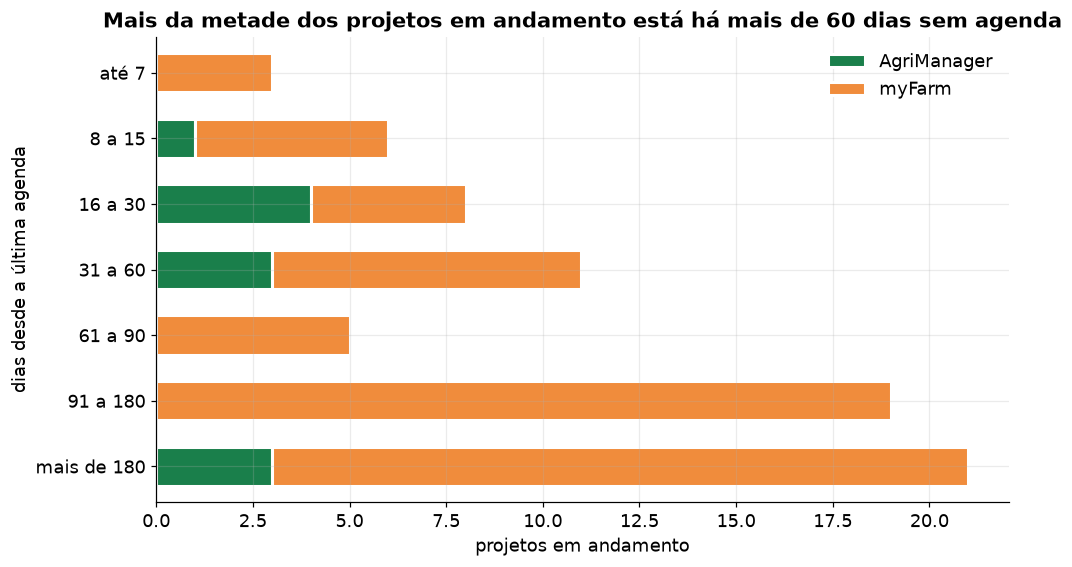

In [18]:
ax = tabela.plot.barh(stacked=True, color=[COR_SISTEMA[c] for c in tabela.columns], width=0.6, edgecolor="white", linewidth=2)
ax.invert_yaxis()
ax.set(title="Mais da metade dos projetos em andamento está há mais de 60 dias sem agenda",
       xlabel="projetos em andamento", ylabel="dias desde a última agenda")
ax.legend(title=None, frameon=False)
plt.show()

In [19]:
sem_nada = andamento[(andamento.DIAS_SEM_AGENDA > 30) & andamento.PROXIMA_AGENDA.isna()]
print("mais de 30 dias sem agenda e nada marcado:", len(sem_nada), "de", len(andamento))

mais de 30 dias sem agenda e nada marcado: 50 de 73


**Resultado:** 50 dos 73 projetos em andamento estão há mais de 30 dias sem agenda e sem nada marcado. Só que "parado" pode ser duas coisas bem diferentes: o cliente que travou no meio da implantação, ou o projeto que já entrou em produção e ninguém encerrou. A fase da jornada separa as duas.

## Em que fase da jornada cada projeto está?
A fase vem da etapa das OS que já aconteceram (a mais avançada). As duas metodologias (myFarm e AgriManager) foram traduzidas pras mesmas sete fases.

In [20]:
etapas = m.agendas[["ETAPA", "FASE"]].drop_duplicates().assign(FASE_NOME=lambda d: d.FASE.map(modelo.FASES).fillna("gestão"))
etapas[etapas.ETAPA.notna()].groupby("FASE_NOME").ETAPA.apply(lambda s: "; ".join(sorted(s)[:4])).to_frame("exemplos de etapa")

,exemplos de etapa
FASE_NOME,
Encerramento,5.0 ENCERRAMENTO - 5.1 APRESENTACAO GANHOS E R...
Go live,3.0 EXECUCAO - 3.3 GO LIVE (ENTRADA EM PRODUCA...
Iniciação,1.0 INICIACAO - 1.1 REUNIAO COM PATROCINADOR; ...
Parametrização,3.0 EXECUCAO - 3.1 PARAMETRIZACAO; ETAPA 04 P...
Planejamento,1.0 INICIACAO - 1.4 INSTALACAO DO ERP; 2.0 PLA...
Pós produção,3.0 EXECUCAO - 3.6 POS PRODUCAO; ETAPA 08 - AC...
Treinamento e simulação,3.0 EXECUCAO - 3.2 SIMULACAO / TREINAMENTOS; C...
gestão,.GERENCIAMENTO PROJETO / STATUS REPORT; 4.0 MO...


In [21]:
ordem = ["Sem agenda de fase"] + list(modelo.FASES.values())
pd.crosstab(andamento.FASE_NOME, andamento.SISTEMA_NOME).reindex(ordem).fillna(0).astype(int)

SISTEMA_NOME,AgriManager,myFarm
FASE_NOME,,
Sem agenda de fase,2,2
Iniciação,1,1
Planejamento,0,0
Parametrização,0,3
Treinamento e simulação,4,17
Go live,1,17
Pós produção,3,22
Encerramento,0,0


In [22]:
parados = andamento[(andamento.DIAS_SEM_AGENDA > 30) & andamento.PROXIMA_AGENDA.isna()]
parados.assign(MOMENTO=parados.FASE_ATUAL.ge(modelo.FASE_GO_LIVE).map({True: "depois do go live", False: "antes do go live"})) \
       .groupby(["MOMENTO", "SISTEMA_NOME"]).agg(projetos=("COD", "size"), saldo_h=("SALDO", "sum"), dias_sem_agenda_mediana=("DIAS_SEM_AGENDA", "median")).round(0)

projetos  saldo_h  dias_sem_agenda_mediana
MOMENTO           SISTEMA_NOME                                            
antes do go live  AgriManager          1      8.0                    223.0
                  myFarm               9    136.0                    139.0
depois do go live AgriManager          4    101.0                    159.0
                  myFarm              36    281.0                    140.0

**Resultado:** dos 50 parados, 40 já passaram do go live (36 deles myFarm). Esses não estão em risco de implantação: estão esperando encerramento, com uns 380 horas de saldo somadas. O problema real são os 10 que pararam antes do go live, há mais de quatro meses em mediana. A fase depende de como o consultor classificou a etapa na OS, então vale como leitura forte, não como certeza [Provável].

Com isso, a régua de saúde do painel separa **Crítico** (parado antes do go live, horas acabando sem go live) de **Encerrar** (go live feito e sem agenda).

## Quais são os projetos parados antes do go live?

In [23]:
criticos = parados[parados.FASE_ATUAL < modelo.FASE_GO_LIVE].sort_values("DIAS_SEM_AGENDA", ascending=False)
criticos[["PROJETO", "GERENTE", "RESPONSAVEL", "FASE_NOME", "ULTIMA_AGENDA", "DIAS_SEM_AGENDA", "UTILIZADAS", "SALDO", "PCT_CONSUMO"]].round({"PCT_CONSUMO": 2})

,PROJETO,GERENTE,RESPONSAVEL,FASE_NOME,ULTIMA_AGENDA,DIAS_SEM_AGENDA,UTILIZADAS,SALDO,PCT_CONSUMO
32,FAZENDA AGUA SANTA - JUSSARA-GO IMPL MYFARM,JAQUELINE NEVES MARTINS,ANDERSON PEDRO CASSOL,Treinamento e simulação,2025-11-13,322,9.0,16.0,0.36
13,PIAZZA AGROPECUARIA - CHAPECO - SC - IMPL MYFARM,YURI LUCAS COELHO,GUILHERME JOB LIMA DE SOUZA,Treinamento e simulação,2026-01-29,245,12.0,13.0,0.48
73,SJB GROUP - EMILIO DIAS - IBIA - MG - IMPL AGM,YURI LUCAS COELHO,FELIPE DA SILVA VERZOTTO,Treinamento e simulação,2026-02-20,223,72.0,8.0,0.90
40,FAZENDA CEDRO E CATINGUEIRO - UNAI - MG - IMPL...,YURI LUCAS COELHO,WARLEN ANDRADE,Treinamento e simulação,2026-04-22,162,8.0,32.0,0.20
21,FAZENDA SERTANEJO - S.J. DA ALIANÇA - GO - IMP...,YURI LUCAS COELHO,GUILHERME JOB LIMA DE SOUZA,Treinamento e simulação,2026-05-12,142,16.0,14.0,0.53
23,FAZENDA CASCATA - NOVA SANTA HELENA - MT - IMP...,YURI LUCAS COELHO,GUILHERME JOB LIMA DE SOUZA,Treinamento e simulação,2026-05-15,139,16.0,14.0,0.53
41,FERTYL LTDA - OURINHOS - GO - IMPL MYFARM,YURI LUCAS COELHO,GUILHERME JOB LIMA DE SOUZA,Treinamento e simulação,2026-05-20,134,38.0,12.0,0.76
68,FAZENDA AGRO CORRENTE - RIACHAO - MA - IMPL MY...,YURI LUCAS COELHO,GUILHERME JOB LIMA DE SOUZA,Treinamento e simulação,2026-07-15,78,24.0,16.0,0.60
4,FAZENDA NOSSA SENHORA DA LUZ - SORRISO MT - IM...,JOYCE KELLY ALVES PEREIRA,LUCAS NOGUEIRA DE LIMA,Treinamento e simulação,2026-07-29,64,8.0,7.0,0.53
53,FAZENDA PAULISTA - CRISTALINA - GO - IMPL MYFARM,YURI LUCAS COELHO,GUILHERME JOB LIMA DE SOUZA,Treinamento e simulação,2026-08-04,58,28.0,12.0,0.70


In [24]:
ab.SAUDE.value_counts().reindex(modelo.SAUDES[::-1] + ["Suspenso"]).to_frame("projetos")

,projetos
SAUDE,
Crítico,10
Encerrar,40
Atenção,15
Em dia,8
Suspenso,10


**Resultado:** os 10 críticos travaram todos em treinamento e simulação, a fase em que o cliente precisa começar a usar o sistema. Nove são myFarm com saldo entre 7 e 32 horas, ou seja, horas pra terminar existem; o que falta é agenda. O SJB Group AgriManager é o único com horas quase no fim (90% usado). Oito dos dez ainda têm o Yuri como analista no CES.

## Quem responde por cada projeto, e o cadastro de analista está em dia?

In [25]:
por_analista = ab.groupby("GERENTE").agg(
    projetos=("COD", "size"),
    criticos=("SAUDE", lambda s: (s == "Crítico").sum()),
    encerrar=("SAUDE", lambda s: (s == "Encerrar").sum()),
    ultima_agenda_mais_recente=("ULTIMA_AGENDA", "max"),
)
por_analista.sort_values("projetos", ascending=False)

,projetos,criticos,encerrar,ultima_agenda_mais_recente
GERENTE,,,,
YURI LUCAS COELHO,40,8,29,2026-09-29
JAQUELINE NEVES MARTINS,15,1,3,2026-09-18
JOYCE KELLY ALVES PEREIRA,14,1,1,2026-09-30
NAIANA MENDONCA COELHO,11,0,7,2026-03-02
KELLY DAYANNE MARTINS BARROS,2,0,0,2018-02-23
MATILDE MARQUES QUEIROZ,1,0,0,2018-12-21


In [26]:
yuri = ab[ab.GERENTE == "YURI LUCAS COELHO"]
quem_atende = m.agendas[m.agendas.COD_PROJETO.isin(yuri.COD) & (m.agendas.DIA >= "2026-07-01") & m.agendas.SITUACAO.isin(["Realizada", "Sem fechar"])]
quem_atende.CONSULTOR.value_counts().head(8).to_frame("agendas desde jul/2026 nos projetos do Yuri")

,agendas desde jul/2026 nos projetos do Yuri
CONSULTOR,
GUILHERME JOB LIMA DE SOUZA,11
LUCAS NOGUEIRA DE LIMA,2
FELIPE DA SILVA VERZOTTO,1


**Resultado:** 54 dos 83 projetos abertos estão no nome de analistas que não estão no time atual de projetos (Yuri, Naiana, e dois cadastros de 2018) [Provável: pela composição do time, pelas reuniões de setembro, em que a Jaqueline relata ter assumido os projetos do Yuri, e porque as OS de setembro no nome do Yuri e da Naiana são só termos de encerramento da força-tarefa]. Só o Yuri soma 40, com 8 críticos e 29 por encerrar. Na prática quem atende esses projetos é o Guilherme Job. Enquanto o CES não for corrigido, qualquer cobrança por analista sai errada; o painel mostra o analista como está no cadastro.

## As agendas planejadas estão acontecendo, e as OS estão sendo fechadas?
Agenda vencida = planejada pra uma data que já passou, sem execução e sem cancelamento. OS sem fechar = agenda confirmada que já passou, sem OS fechada (não conta como hora usada).

In [27]:
ag_abertos = m.agendas[m.agendas.COD_PROJETO.isin(ab.COD)].merge(ab[["COD", "GERENTE"]], left_on="COD_PROJETO", right_on="COD")
ag_abertos.SITUACAO.value_counts().to_frame("agendas")

,agendas
SITUACAO,
Realizada,545
Vencida,167
Próxima,125
Sem fechar,17


In [28]:
vencidas = ag_abertos[ag_abertos.SITUACAO == "Vencida"]
print("projetos com agenda vencida:", vencidas.COD_PROJETO.nunique(), "| a mais antiga:", vencidas.DIA.min().date())
vencidas.groupby(vencidas.DIA.dt.year).size().to_frame("agendas vencidas por ano")

projetos com agenda vencida: 57 | a mais antiga: 2019-11-04


,agendas vencidas por ano
DIA,
2019,5
2021,1
2024,5
2025,47
2026,109


In [29]:
sem_fechar = ag_abertos[ag_abertos.SITUACAO == "Sem fechar"]
sem_fechar.groupby("CONSULTOR").agg(agendas=("OS", "size"), horas=("HORAS", "sum"), mais_antiga=("DIA", "min")).sort_values("horas", ascending=False)

,agendas,horas,mais_antiga
CONSULTOR,,,
JAQUELINE NEVES MARTINS,5,5.0,2025-11-07
JOYCE KELLY ALVES PEREIRA,5,5.0,2026-07-24
YURI LUCAS COELHO,5,5.0,2025-12-05
WARLEN ANDRADE,1,4.0,2026-05-12
NAIANA MENDONCA COELHO,1,1.0,2025-04-23


**Resultado:** a agenda planejada não é confiável como previsão. 57 dos 83 projetos têm agendas que passaram sem execução e continuam lá como planejadas, quase todas de 2025 e 2026; na prática foram remarcadas em outra OS ou simplesmente não aconteceram, e ninguém cancelou. Já o fechamento de OS está em dia: o que sobra confirmado sem fechar são 20 horas, quase tudo reunião de abertura de 1 hora das analistas.

## Quanto cada consultor atendeu nos projetos hunter, e quanto tem pela frente?
Últimos 90 dias de agenda realizada, contra o que está marcado nos próximos 30 dias.

In [30]:
ag = m.agendas.merge(m.hunter[["COD", "SISTEMA_NOME"]], left_on="COD_PROJETO", right_on="COD")
recentes = ag[(ag.SITUACAO == "Realizada") & (ag.DIA > m.ref - pd.Timedelta(days=90))]
futuras = ag[(ag.SITUACAO == "Próxima") & (ag.DIA <= m.ref + pd.Timedelta(days=30))]
carga = pd.DataFrame({
    "horas_90d": recentes.groupby("CONSULTOR").HORAS.sum(),
    "projetos_90d": recentes.groupby("CONSULTOR").COD_PROJETO.nunique(),
    "horas_marcadas_30d": futuras.groupby("CONSULTOR").HORAS.sum(),
}).fillna(0).sort_values("horas_90d", ascending=False)
carga.head(12)

,horas_90d,projetos_90d,horas_marcadas_30d
CONSULTOR,,,
FELIPE DA SILVA VERZOTTO,105.8,3,140.0
GUILHERME JOB LIMA DE SOUZA,98.0,15,100.0
LUCAS NOGUEIRA DE LIMA,82.0,10,56.0
LEONARDO BORGES MENDONÇA,56.5,2,24.0
NAIANA MENDONCA COELHO,37.0,5,0.0
YURI LUCAS COELHO,32.0,7,0.0
JOYCE KELLY ALVES PEREIRA,31.0,11,2.0
JAQUELINE NEVES MARTINS,21.0,6,6.0
RHEIDER TELES SILVEIRA,5.0,1,72.0


In [31]:
resp = ab[ab.STATUS == "EM ANDAMENTO"].groupby("RESPONSAVEL").agg(projetos_como_responsavel=("COD", "size"),
                                                                   criticos=("SAUDE", lambda s: (s == "Crítico").sum()))
resp.join(carga, how="left").fillna(0).sort_values("projetos_como_responsavel", ascending=False)

,projetos_como_responsavel,criticos,horas_90d,projetos_90d,horas_marcadas_30d
RESPONSAVEL,,,,,
GUILHERME JOB LIMA DE SOUZA,30,6,98.0,15.0,100.0
ANDERSON PEDRO CASSOL,9,1,0.0,0.0,0.0
LUCAS NOGUEIRA DE LIMA,9,1,82.0,10.0,56.0
WARLEN ANDRADE,8,1,0.0,0.0,0.0
FELIPE DA SILVA VERZOTTO,8,1,105.8,3.0,140.0
RAFAEL ALBINO SANTANA,4,0,0.0,0.0,0.0
INÁCIO JOSÉ DE OLIVEIRA NETO,2,0,0.0,0.0,0.0
CONSULTOR A DEFINIR,1,0,0.0,0.0,0.0
LEONARDO BORGES MENDONÇA,1,0,56.5,2.0,24.0


**Resultado:** o cadastro de consultor responsável também está desatualizado. Anderson, Warlen, Rafael e Inácio somam 23 projetos em andamento como responsáveis e nenhuma hora de agenda hunter nos últimos 90 dias; quem carrega a implantação myFarm hoje é o Guilherme (15 projetos atendidos no período) e o Lucas (10). No AgriManager, Felipe concentra o atendimento e tem a agenda mais cheia dos próximos 30 dias. Por isso o painel mostra os dois: o responsável do cadastro e quem de fato atendeu.

## Como a carteira hunter evoluiu mês a mês?
Entradas (abertura), encerramentos (data final dos concluídos) e o tamanho da carteira em andamento no fim de cada mês, desde 2025. Encerramento aqui é a entrega pro suporte (DT_ENTREGA_SUPORTE); a DT_FINAL marca só o fim da execução.

In [32]:
hu = m.hunter[m.hunter.STATUS != "CANCELADO"]
meses = pd.period_range("2025-01", m.ref.to_period("M"), freq="M")
concl = hu[hu.STATUS == "CONCLUIDO"]
entradas = hu.groupby([hu.DT_INICIAL.dt.to_period("M"), "SISTEMA_NOME"]).size().unstack(fill_value=0).reindex(meses, fill_value=0)
saidas = concl.groupby([concl.DT_ENCERRAMENTO.dt.to_period("M"), "SISTEMA_NOME"]).size().unstack(fill_value=0).reindex(meses, fill_value=0)
fim_mes = meses.to_timestamp(how="end")
base = hu[hu.STATUS.isin(["EM ANDAMENTO", "CONCLUIDO"])]
carteira = pd.DataFrame({s: [((g.DT_INICIAL <= d) & (g.DT_ENCERRAMENTO.isna() | (g.DT_ENCERRAMENTO > d))).sum() for d in fim_mes]
                         for s, g in base.groupby("SISTEMA_NOME")}, index=meses)
pd.concat({"entradas": entradas, "encerramentos": saidas, "carteira no fim do mês": carteira}, axis=1).tail(10)

entradas        encerramentos        carteira no fim do mês  \
SISTEMA_NOME AgriManager myFarm   AgriManager myFarm            AgriManager   
2026-01                0      3             0      1                      8   
2026-02                0      7             0      0                      8   
2026-03                3      8             0      0                     11   
2026-04                1      3             1      0                     11   
2026-05                1      4             0      0                     12   
2026-06                0      1             0      1                     12   
2026-07                1      7             1      6                     12   
2026-08                2      6             1      0                     13   
2026-09                1      2             3      7                     11   
2026-10                0      0             0      0                     11   

                     
SISTEMA_NOME myFarm  
2026-01          38  
2026-02          45  
2026-03          53  
2026-04          56  
2026-05          60  
2026-06          60  
2026-07          61  
2026-08          67  
2026-09          62  
2026-10          62

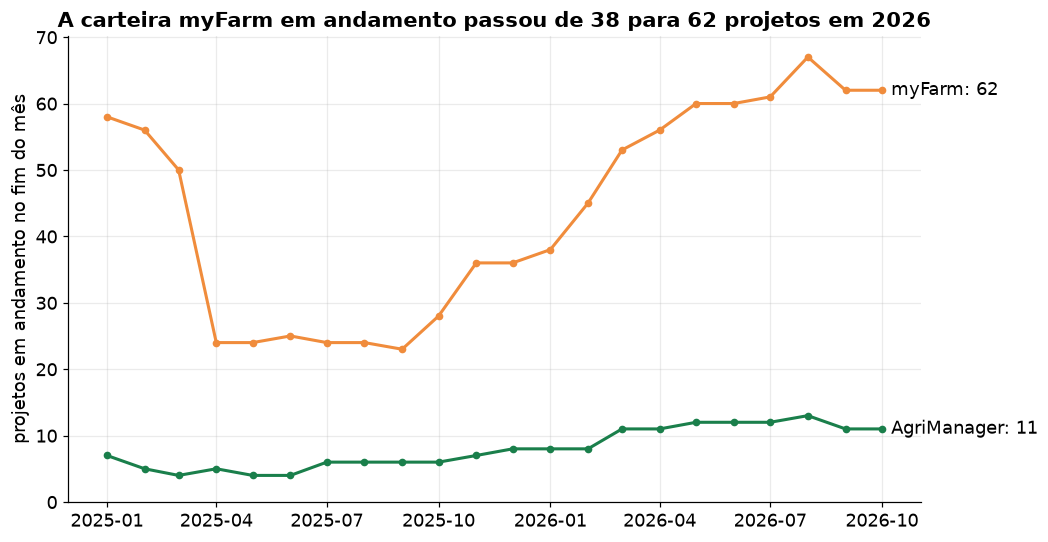

In [33]:
fig, ax = plt.subplots()
for s in carteira.columns:
    ax.plot(carteira.index.to_timestamp(), carteira[s], color=COR_SISTEMA[s], linewidth=2, marker="o", markersize=4)
    ax.annotate(f"{s}: {carteira[s].iloc[-1]}", (carteira.index[-1].to_timestamp(), carteira[s].iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center")
ax.set(title="A carteira myFarm em andamento passou de 38 para 62 projetos em 2026", ylabel="projetos em andamento no fim do mês")
ax.set_ylim(0)
plt.show()

In [34]:
saidas.loc["2025-01":"2025-06"]

SISTEMA_NOME,AgriManager,myFarm
2025-01,7,5
2025-02,2,4
2025-03,1,11
2025-04,0,28
2025-05,2,6
2025-06,2,4


**Resultado:** a carteira myFarm anda em ondas. Ela encheu até o começo de 2025, caiu de uma vez em abril/2025 (28 encerramentos num mês só, uma limpeza) e voltou a encher ao longo de 2026, até 67 em agosto. A força-tarefa de setembro encerrou 7 e a curva virou, mas o tamanho atual é o reflexo dos 40 projetos que já fizeram go live e seguem abertos. Encerrar no ritmo das entradas, em vez de em mutirão, é o que tira a carteira dessa onda. No AgriManager a carteira é pequena e estável.

## O ritmo de atendimento acompanha a carteira?
Horas realizadas por mês em todos os projetos hunter (abertos e já encerrados), desde 2025.

In [35]:
realizadas = ag[(ag.SITUACAO == "Realizada") & (ag.DIA >= "2025-01-01")]
horas_mes = realizadas.groupby([realizadas.DIA.dt.to_period("M"), "SISTEMA_NOME"]).HORAS.sum().unstack(fill_value=0)
horas_mes.tail(10).round(0)

SISTEMA_NOME,AgriManager,myFarm
DIA,,
2025-12,83.0,200.0
2026-01,80.0,213.0
2026-02,85.0,115.0
2026-03,158.0,148.0
2026-04,65.0,149.0
2026-05,42.0,170.0
2026-06,104.0,145.0
2026-07,71.0,85.0
2026-08,124.0,88.0


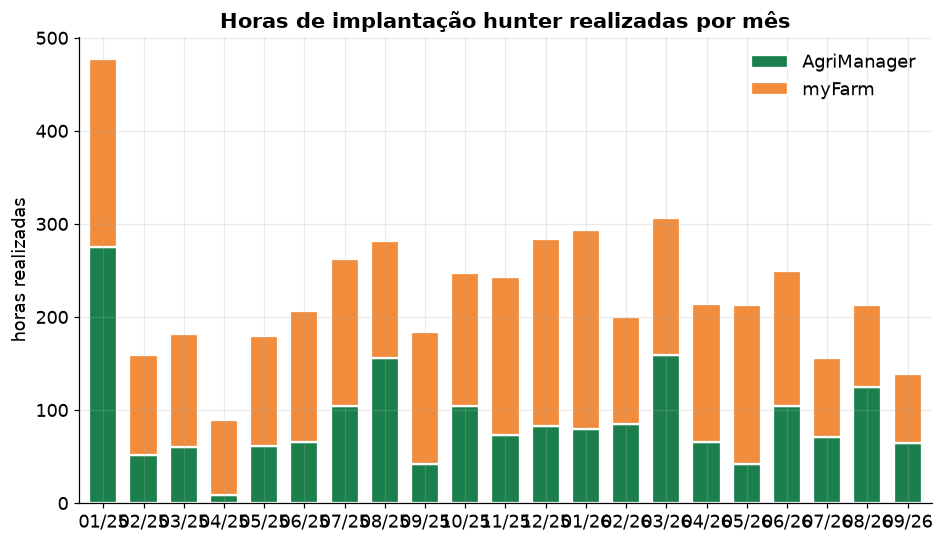

In [36]:
ax = horas_mes.plot.bar(stacked=True, color=[COR_SISTEMA[c] for c in horas_mes.columns], width=0.7, edgecolor="white", linewidth=1.5)
ax.set_xticklabels([p.strftime("%m/%y") for p in horas_mes.index], rotation=0)
ax.set(title="Horas de implantação hunter realizadas por mês", xlabel=None, ylabel="horas realizadas")
ax.legend(title=None, frameon=False)
plt.show()

In [37]:
mf = realizadas[realizadas.SISTEMA_NOME == "myFarm"]
ritmo = pd.DataFrame({
    "horas": mf.groupby(mf.DIA.dt.to_period("M")).HORAS.sum(),
    "consultores que atenderam": mf[mf.HORAS >= 2].groupby(mf.DIA.dt.to_period("M")).CONSULTOR.nunique(),
    "carteira no fim do mês": carteira["myFarm"],
}).loc["2025-07":]
ritmo["horas por projeto da carteira"] = ritmo.horas / ritmo["carteira no fim do mês"]
ritmo.round(1)

,horas,consultores que atenderam,carteira no fim do mês,horas por projeto da carteira
2025-07,158.0,3.0,24,6.6
2025-08,125.5,4.0,24,5.2
2025-09,141.5,4.0,23,6.2
2025-10,143.2,4.0,28,5.1
2025-11,170.0,2.0,36,4.7
2025-12,200.5,3.0,36,5.6
2026-01,213.0,3.0,38,5.6
2026-02,115.0,4.0,45,2.6
2026-03,148.0,2.0,53,2.8
2026-04,149.0,2.0,56,2.7


**Resultado:** o atendimento myFarm caiu pela metade a partir de julho/2026 (de 145 a 210 horas por mês pra 75 a 90), enquanto a carteira subiu. O número de consultores com agenda no mês não caiu junto, então os dados não mostram a causa; a queda não é falta de gente atendendo, é menos hora por consultor nos projetos hunter [Suposição: agenda dividida com outras frentes]. A conta de horas por projeto exagera a queda, porque a carteira está inflada pelos 40 projetos que já passaram do go live e não precisam de hora. Mesmo assim, os 10 críticos estão parados em treinamento e simulação justamente nesse período.

## Quais projetos atacar primeiro?
Ordem de ataque (mesma do painel, aba Prioridades): primeiro o crítico sem agenda marcada, depois quem ainda implanta e está sem próxima agenda, depois quem só falta encerrar, depois quem já tem agenda e, por último, os suspensos. Dentro de cada grupo, quem está há mais tempo sem agenda vem antes. Do lado de cada projeto, a última OS executada e a próxima agenda.

In [38]:
grupos = ab.groupby("PRIORIDADE_GRUPO").agg(projetos=("COD", "size"), saldo_h=("SALDO", "sum"), dias_sem_agenda_mediana=("DIAS_SEM_AGENDA", "median"))
grupos.reindex(modelo.GRUPOS_PRIORIDADE).round(0)

,projetos,saldo_h,dias_sem_agenda_mediana
PRIORIDADE_GRUPO,,,
Crítico sem agenda,10,144.0,140.0
Sem agenda marcada,3,39.0,13.0
Encerrar,40,382.0,140.0
Com agenda marcada,20,821.0,22.0
Suspenso,10,378.0,782.0


In [39]:
fila = ab.sort_values("PRIORIDADE")
fila[["PRIORIDADE", "PRIORIDADE_GRUPO", "PROJETO", "ULTIMA_AGENDA", "ULTIMA_OS", "ULTIMA_OS_ETAPA", "ULTIMA_OS_CONSULTOR", "PROXIMA_AGENDA", "SALDO"]].head(13).astype({"ULTIMA_OS": "Int64"})

,PRIORIDADE,PRIORIDADE_GRUPO,PROJETO,ULTIMA_AGENDA,ULTIMA_OS,ULTIMA_OS_ETAPA,ULTIMA_OS_CONSULTOR,PROXIMA_AGENDA,SALDO
32,1,Crítico sem agenda,FAZENDA AGUA SANTA - JUSSARA-GO IMPL MYFARM,2025-11-13,30042901,TREINAMENTO E SIMULAÇÃO I,ANDERSON PEDRO CASSOL,NaT,16.0
13,2,Crítico sem agenda,PIAZZA AGROPECUARIA - CHAPECO - SC - IMPL MYFARM,2026-01-29,30044115,TREINAMENTO E SIMULAÇÃO II,GUILHERME JOB LIMA DE SOUZA,NaT,13.0
73,3,Crítico sem agenda,SJB GROUP - EMILIO DIAS - IBIA - MG - IMPL AGM,2026-02-20,30045320,3.0 EXECUCAO - 3.1 PARAMETRIZACAO,FELIPE DA SILVA VERZOTTO,NaT,8.0
40,4,Crítico sem agenda,FAZENDA CEDRO E CATINGUEIRO - UNAI - MG - IMPL...,2026-04-22,30046415,TREINAMENTO E SIMULAÇÃO III,WARLEN ANDRADE,NaT,32.0
21,5,Crítico sem agenda,FAZENDA SERTANEJO - S.J. DA ALIANÇA - GO - IMP...,2026-05-12,30046744,TREINAMENTO E SIMULAÇÃO III,GUILHERME JOB LIMA DE SOUZA,NaT,14.0
23,6,Crítico sem agenda,FAZENDA CASCATA - NOVA SANTA HELENA - MT - IMP...,2026-05-15,30045179,TREINAMENTO E SIMULAÇÃO III,WARLEN ANDRADE,NaT,14.0
41,7,Crítico sem agenda,FERTYL LTDA - OURINHOS - GO - IMPL MYFARM,2026-05-20,30046004,TREINAMENTO E SIMULAÇÃO III,GUILHERME JOB LIMA DE SOUZA,NaT,12.0
68,8,Crítico sem agenda,FAZENDA AGRO CORRENTE - RIACHAO - MA - IMPL MY...,2026-07-15,30044736,TREINAMENTO E SIMULAÇÃO III,GUILHERME JOB LIMA DE SOUZA,NaT,16.0
4,9,Crítico sem agenda,FAZENDA NOSSA SENHORA DA LUZ - SORRISO MT - IM...,2026-07-29,30048870,3.0 EXECUCAO - 3.1 PARAMETRIZACAO,LUCAS NOGUEIRA DE LIMA,NaT,7.0
53,10,Crítico sem agenda,FAZENDA PAULISTA - CRISTALINA - GO - IMPL MYFARM,2026-08-04,30045508,TREINAMENTO E SIMULAÇÃO III,GUILHERME JOB LIMA DE SOUZA,NaT,12.0


**Resultado:** a fila de ataque tem 13 projetos na frente: os 10 críticos e 3 que ainda estão implantando, tiveram agenda há 2 a 14 dias e só precisam da próxima marcada. Nos críticos a última OS conta onde o projeto travou: em 6 dos 10 foi o Treinamento e Simulação III, a última etapa antes do go live no método myFarm. O cliente foi treinado e não entrou em produção, então o gargalo é a virada pra produção, não o treinamento [Provável]. Dois deles (Cedro e Catingueiro, Cascata) tiveram a última agenda com o Warlen em abril e maio, e ele não atende mais implantação hunter: pra esses, a primeira pergunta é de quem é o projeto. Os 40 por encerrar vêm depois, e quase todo o saldo com agenda está nos 20 que já têm data marcada.

## Como está a agenda dos consultores nas próximas semanas?
Aqui entram todas as OS da exportação, não só hunter: a agenda do consultor inclui treinamento, consultoria, DBA e outros serviços. Soma das horas por consultor e semana (realizadas, confirmadas sem fechar e marcadas), da semana da posição em diante.

In [40]:
g = m.agenda_geral
conta = g[g.SITUACAO.isin(["Realizada", "Sem fechar", "Próxima"])]
seg0 = m.ref - pd.Timedelta(days=m.ref.weekday())
prox = conta[(conta.DIA >= seg0) & (conta.DIA < seg0 + pd.Timedelta(weeks=4))]
semanas = prox.assign(SEMANA=prox.DIA.dt.to_period("W-SUN").dt.start_time)
tabela_sem = semanas.pivot_table(index="CONSULTOR", columns="SEMANA", values="HORAS", aggfunc="sum", fill_value=0)
tabela_sem.columns = [c.strftime("semana %d/%m") for c in tabela_sem.columns]
tabela_sem["% hunter"] = (semanas[semanas.HUNTER].groupby("CONSULTOR").HORAS.sum().reindex(tabela_sem.index).fillna(0) / tabela_sem.sum(axis=1)).round(2)
tabela_sem.sort_values(tabela_sem.columns[1], ascending=False)

,semana 28/09,semana 05/10,semana 12/10,semana 19/10,% hunter
CONSULTOR,,,,,
FELIPE DA SILVA VERZOTTO,16.0,44.0,32.0,40.0,0.82
GUILHERME JOB LIMA DE SOUZA,8.0,32.0,32.0,16.0,0.95
LUCAS NOGUEIRA DE LIMA,18.0,24.0,25.0,24.0,0.60
FABIO ANTONIO OLIVEIRA NOVAIS,0.0,20.0,0.0,0.0,0.00
LEONARDO BORGES MENDONÇA,40.0,16.0,0.0,36.0,0.00
JAQUELINE NEVES MARTINS,0.0,0.0,2.0,2.0,1.00
IGOR SOUSA FERRAZ ARAGAO,0.0,0.0,0.0,0.0,NaN
JOYCE KELLY ALVES PEREIRA,2.0,0.0,1.0,0.0,1.00
RHEIDER TELES SILVEIRA,32.5,0.0,32.0,40.0,0.69


**Resultado:** nas duas próximas semanas o Felipe já passa das 40 horas (44h na semana de 05/10), e o Rheider e o Leonardo têm semanas cheias alternadas. Os dois consultores myFarm têm folga: o Guilherme está com 32h marcadas e o Lucas com 24h a 25h por semana, ou seja, 8 a 16 horas livres em cada semana. É nessa folga que cabem os 13 projetos myFarm sem agenda marcada da fila de ataque. Ressalva forte: a exportação do CES parece não trazer a agenda inteira de todo mundo (o Fábio, que tem agenda cheia até dezembro, aparece com só 20h), então "livre" aqui quer dizer "sem OS nesta planilha" [Provável].

## Quanto atendimento aconteceu nos últimos 30 dias, e em que tipo de projeto?
Agendas realizadas (ou confirmadas sem fechar) de 02/09 a 01/10/2026, todos os projetos.

In [41]:
ult30 = g[g.SITUACAO.isin(["Realizada", "Sem fechar"]) & (g.DIA > m.ref - pd.Timedelta(days=30)) & (g.DIA <= m.ref)]
ult30 = ult30.assign(TIPO=ult30.HUNTER.map({True: "hunter", False: "farmer e outros"}))
resumo30 = ult30.pivot_table(index="CONSULTOR", columns="TIPO", values="HORAS", aggfunc="sum", fill_value=0)
resumo30["total"] = resumo30.sum(axis=1)
resumo30["agendas"] = ult30.groupby("CONSULTOR").size()
print("agendas:", len(ult30), "| horas:", ult30.HORAS.sum(), "| % hunter:", round(ult30[ult30.HUNTER].HORAS.sum() / ult30.HORAS.sum(), 2))
resumo30.sort_values("total", ascending=False)

agendas: 97 | horas: 458.0 | % hunter: 0.3


TIPO,farmer e outros,hunter,total,agendas
CONSULTOR,,,,
LEONARDO BORGES MENDONÇA,150.0,0.0,150.0,21
LUCAS NOGUEIRA DE LIMA,60.5,22.0,82.5,19
RHEIDER TELES SILVEIRA,41.2,0.0,41.2,10
GUILHERME JOB LIMA DE SOUZA,18.0,22.0,40.0,11
NAIANA MENDONCA COELHO,0.0,37.0,37.0,7
WALLYSON TOBIAS GOMES DA SILVA,33.0,0.0,33.0,4
FELIPE DA SILVA VERZOTTO,8.0,15.8,23.8,9
YURI LUCAS COELHO,0.0,21.0,21.0,4
JAQUELINE NEVES MARTINS,0.0,14.0,14.0,5


**Resultado:** só 30% das 458 horas do último mês foram em projetos hunter, e cerca de 40% dessas horas hunter estão no nome do Yuri e da Naiana, que são os termos de encerramento da força-tarefa (visto acima). Atendimento de implantação de fato, no mês: uns 60 horas, divididas entre Guilherme, Lucas e Felipe. O Guilherme, responsável por 30 projetos no cadastro, fez 40 horas de agenda no mês inteiro, e o Lucas gastou três quartos das horas dele em treinamento e demandas internas. Isso completa a leitura da queda do atendimento myFarm desde julho: além da carteira cheia de projeto que já deveria estar encerrado, pouca hora de consultor está indo pra implantação [Provável, com a mesma ressalva de cobertura da exportação].

## Quantos projetos precisam ser atacados, e há quanto tempo estão parados?
Projetos em andamento sem nenhuma agenda marcada (a aba "Projetos a atacar" do painel), por faixa de dias sem agenda e pelo que precisa ser feito.

In [42]:
atacar = ab[(ab.STATUS != "SUSPENSO") & ab.PROXIMA_AGENDA.isna()]
atacar = atacar.assign(ACAO=atacar.PRIORIDADE_GRUPO.map(lambda g: "encerrar" if g == "Encerrar" else "retomar"),
                       FAIXA=pd.cut(atacar.DIAS_SEM_AGENDA, [-1, 30, 90, 10_000], labels=["até 30 dias", "31 a 90", "mais de 90"]))
pd.crosstab(atacar.FAIXA, atacar.ACAO, margins=True, margins_name="Total")

ACAO,encerrar,retomar,Total
FAIXA,,,
até 30 dias,0,3,3
31 a 90,8,3,11
mais de 90,32,7,39
Total,40,13,53


**Resultado:** 53 projetos em andamento estão sem nada marcado, e 39 deles há mais de 90 dias. A maioria (40) é encerramento, quase todos parados há mais de três meses, o que confirma que a carteira acumula projeto terminado sem papel. Os 13 a retomar são poucos, mas 7 já passaram de 90 dias: esses são os que mais arriscam virar cancelamento. Só 3 estão parados há menos de um mês, e são justamente os que só precisam da próxima agenda.

## As agendas trazem horário de início e fim?
O CES guarda entrada e saída de cada período (manhã, tarde e noite) na OS executada e início e fim da manhã e da tarde na OS planejada; 00:00 é campo vazio. Conferindo quanto das agendas tem horário, por situação, e se o horário bate com as horas lançadas.

In [43]:
cobertura = g.assign(TEM_HORARIO=g.INICIO.notna()).groupby("SITUACAO").agg(agendas=("OS", "size"), com_horario=("TEM_HORARIO", "mean"))
cobertura.round(3)

,agendas,com_horario
SITUACAO,,
Próxima,189,0.952
Realizada,16636,1.000
Sem fechar,552,1.000
Vencida,681,0.916


In [44]:
def horas_do_horario(periodos):
    return sum((pd.Timestamp(f"2000-01-01 {b}") - pd.Timestamp(f"2000-01-01 {a}")).seconds / 3600 for a, b in periodos)

realizadas_h = g[(g.SITUACAO == "Realizada") & g.INICIO.notna()]
diferenca = (realizadas_h.PERIODOS.map(horas_do_horario) - realizadas_h.HORAS).round(2)
diferenca.describe(percentiles=[.05, .5, .95]).to_frame("horário - horas lançadas").T

,count,mean,std,min,5%,50%,95%,max
horário - horas lançadas,16636.0,-0.000563,0.057164,-6.0,0.0,0.0,0.0,1.0


**Resultado:** o horário é confiável. Toda agenda que aconteceu tem início e fim, e a soma dos períodos bate com as horas lançadas na OS em praticamente todos os casos (só exceções isoladas). Nas marcadas falta horário em 1 de cada 20, então o painel mostra "horário não informado no CES" quando vier vazio. Uma correção saiu daqui: quando o CES parte o mesmo dia de uma OS planejada em duas linhas, o modelo agora soma as duas, em vez de ficar só com a primeira (não mudou nenhum número dos projetos hunter).

## Os reports das analistas cobrem os mesmos projetos do painel?
Os arquivos "Report Projetos myFarm" e "Report Projetos AgriManager" são exportações filtradas do CES em que a analista anotou, projeto a projeto, andamento, previsão de encerramento, status financeiro, HandOff e analista de sucesso. A ligação com o painel é o código do projeto (COD). A leitura fica em `importar_reports.py`, que também grava o histórico usado pelo painel.

In [45]:
import importar_reports
rep = importar_reports.ler_reports(".")
print("anotações:", len(rep), "| projetos:", rep.cod.nunique(), "| arquivos:", rep.arquivo.unique().tolist())
pd.Series({
    "no report e em aberto no painel": rep.cod.isin(ab.COD).sum(),
    "no report, hunter já fechado no CES": (rep.cod.isin(m.hunter.COD) & ~rep.cod.isin(ab.COD)).sum(),
    "no report e fora do hunter": (~rep.cod.isin(m.hunter.COD)).sum(),
    "em aberto no painel sem report": (~ab.COD.isin(rep.cod)).sum(),
}).to_frame("projetos")

anotações: 97 | projetos: 97 | arquivos: ['Report Projetos AgriManager.xlsx', 'Report Projetos Myfarm.xlsx']


,projetos
no report e em aberto no painel,72
"no report, hunter já fechado no CES",24
no report e fora do hunter,1
em aberto no painel sem report,11


In [46]:
ab[~ab.COD.isin(rep.cod)].STATUS.value_counts().to_frame("abertos sem report")

,abertos sem report
STATUS,
SUSPENSO,10
EM ANDAMENTO,1


**Resultado:** os reports cobrem todos os projetos em andamento do painel, menos um aberto em 28/09 (Fazenda Barreiro); os suspensos ficaram de fora porque o filtro do report só pegou em andamento e pendência. Os 24 que o CES já fechou continuam no report com a anotação do fechamento, então o histórico guarda também o que já saiu. Cada projeto tem uma linha por report, com três anotações (andamento, HandOff e analista de sucesso): "mais de uma anotação por projeto" aqui são campos diferentes, não linhas repetidas; o histórico passa a ter mais de uma linha quando chegar um report novo.

## O status anotado no report bate com o do CES e com a saúde do painel?
A analista mudou à mão a coluna STATUS do report. Comparando com o status do CES e com a régua de saúde do painel.

In [47]:
cruz = rep.merge(m.hunter[["COD", "STATUS"]].rename(columns={"COD": "cod", "STATUS": "status_ces"}), on="cod", how="left") \
          .merge(ab[["COD", "SAUDE"]].rename(columns={"COD": "cod"}), on="cod", how="left")
pd.crosstab(cruz.status.replace("", "(vazio)"), cruz.status_ces.fillna("fora do hunter"))

status_ces,CANCELADO,CONCLUIDO,EM ANDAMENTO,fora do hunter
status,,,,
Cancelado,14,0,0,1
Concluido,0,9,0,0
Em andamento,0,1,42,0
Encerramento,0,0,30,0


In [48]:
pd.crosstab(cruz.status.replace("", "(vazio)"), cruz.SAUDE.fillna("fechado no CES"))

SAUDE,Atenção,Crítico,Em dia,Encerrar,fechado no CES
status,,,,,
Cancelado,0,0,0,0,15
Concluido,0,0,0,0,9
Em andamento,13,6,8,15,1
Encerramento,1,4,0,25,0


**Resultado:** onde o CES já fechou, o report concorda (cancelado e concluído batem um a um). A diferença está no meio do caminho: a analista marcou 30 projetos como "Encerramento", um estado que o CES não tem, e todos seguem em andamento lá. Isso confirma a leitura do painel: 25 deles são exatamente os que o painel chama de "Encerrar". Duas divergências pedem conversa com a analista: 15 projetos que o painel vê como go live feito e parados ela ainda chama de "em andamento", e 4 dos 10 críticos ela já trata como encerramento, ou seja, devem sair da lista de retomar e ir para a de encerrar sem go live [Provável, depende da conversa].

## As horas do report batem com as do CES?
Comparando o realizado e o estoque de horas do report com as horas usadas e o saldo calculados pelo painel, nos 72 projetos em aberto que estão nos dois.

In [49]:
horas_cmp = rep.merge(ab[["COD", "PROJETO", "ADQUIRIDAS", "UTILIZADAS", "SALDO", "PREVISTO"]].rename(columns={"COD": "cod"}), on="cod")
horas_cmp = horas_cmp.assign(dif_realizado=horas_cmp.realizado - horas_cmp.UTILIZADAS, dif_estoque=horas_cmp.estoque - horas_cmp.SALDO,
                             adq_igual_previsto=horas_cmp.hr_adq == horas_cmp.PREVISTO)
pd.Series({"projetos": len(horas_cmp), "realizado igual (±0,5h)": (horas_cmp.dif_realizado.abs() <= .5).sum(),
           "report com menos horas realizadas": (horas_cmp.dif_realizado < -.5).sum(), "report com mais": (horas_cmp.dif_realizado > .5).sum(),
           "HR ADQ do report = previsto do CES": horas_cmp.adq_igual_previsto.sum()}).to_frame("n")

,n
projetos,72
"realizado igual (±0,5h)",41
report com menos horas realizadas,18
report com mais,13
HR ADQ do report = previsto do CES,68


In [50]:
extra = ab.set_index("COD")[["HORAS_SEM_FECHAR", "ULTIMA_AGENDA"]]
horas_cmp = horas_cmp.join(extra, on="cod")
horas_cmp["explica_sem_fechar"] = (horas_cmp.realizado - horas_cmp.UTILIZADAS - horas_cmp.HORAS_SEM_FECHAR).abs() <= .5
horas_cmp.assign(sentido=pd.cut(horas_cmp.dif_realizado, [-1e9, -.5, .5, 1e9], labels=["report menor", "igual", "report maior"])) \
         .groupby("sentido", observed=True).agg(projetos=("cod", "size"), dif_media_h=("dif_realizado", "mean"),
                                                 sem_fechar_explica=("explica_sem_fechar", "sum"), ultima_agenda_mediana=("ULTIMA_AGENDA", "median")).round({"dif_media_h": 1})

,projetos,dif_media_h,sem_fechar_explica,ultima_agenda_mediana
sentido,,,,
report menor,18,-6.8,0,2026-09-09
igual,41,0.0,41,2026-06-03
report maior,13,1.3,12,2026-04-24


**Resultado:** as horas batem em 41 dos 72 projetos, e as diferenças têm explicação. Quando o report tem mais horas, quase sempre (12 de 13) é porque ele conta a agenda confirmada que ainda está com OS sem fechar, que o painel deixa à parte. Quando tem menos (18), são projetos com agenda recente: o report foi tirado antes da exportação do CES e não pegou as últimas agendas [Provável]. O "HR ADQ" do report é o previsto vendido (bate com o CES em 68 de 72), sem as horas bonificadas e transferidas, por isso o estoque do report pode ficar abaixo do saldo do painel. Conclusão prática: para hora e saldo, vale o CES; o report vale pela anotação e pelo financeiro, que o CES não traz.

## Quanto já foi realizado sem estar faturado?
O report traz o faturado (horas faturadas) e o financeiro, que nas contas é faturado menos realizado: negativo quer dizer hora entregue que ainda não foi faturada.

In [51]:
fin = rep.assign(aberto_no_ces=rep.cod.isin(ab.COD))
pd.Series({
    "financeiro bate com faturado − realizado": ((fin.faturado - fin.realizado - fin.financeiro).abs() <= .5).sum(),
    "projetos com financeiro negativo": (fin.financeiro < 0).sum(),
    "horas entregues sem faturar": -fin.loc[fin.financeiro < 0, "financeiro"].sum(),
    "projetos com faturado zero": (fin.faturado == 0).sum(),
    "dos com faturado zero, ainda abertos no CES": ((fin.faturado == 0) & fin.aberto_no_ces).sum(),
}).to_frame("valor")

,valor
financeiro bate com faturado − realizado,97.00
projetos com financeiro negativo,12.00
horas entregues sem faturar,367.42
projetos com faturado zero,14.00
"dos com faturado zero, ainda abertos no CES",11.00


In [52]:
fin[fin.financeiro < 0].sort_values("financeiro")[["projeto", "status", "hr_adq", "realizado", "faturado", "financeiro"]].head(12)

,projeto,status,hr_adq,realizado,faturado,financeiro
78,PROJETO COAP - SORRISO-MT - IMPL MYFARM,Cancelado,120.0,131.75,0.0,-131.75
59,PROJETO COAP 2 - SORRISO - MT - IMPL MYFARM,Cancelado,80.0,44.00,0.0,-44.00
48,FAZENDA ARIRANHA - JATAI - GO - IMPL MYFARM,Encerramento,45.0,36.00,0.0,-36.00
69,FAZENDA PRIMAVERA - RIO VERDE - GO IMPL MYFARM,Encerramento,30.0,27.00,0.0,-27.00
76,FAZENDA OURO VERDE - VILA RICA-MT - IMP MYFARM,Encerramento,25.0,25.00,0.0,-25.00
93,SENAR - FAZENDA SEGREDO - TREINAMENTO MYFARM,Em andamento,35.0,24.67,0.0,-24.67
57,FACULDADE QUIRINOPOLIS - FAQUI - QUIRINOPOLIS ...,Encerramento,25.0,20.00,0.0,-20.00
88,CGS BRASIL - SINOP - MT - IMPL MYFARM,Concluido,25.0,20.00,0.0,-20.00
95,AGROPECUARIA CRUVINEL - PORTO ALEGRE - IMPL MY...,Em andamento,39.0,20.00,0.0,-20.00
27,FAZENDA NOSSA SENHORA DA LUZ - SORRISO MT - IM...,Encerramento,15.0,9.00,0.0,-9.00


**Resultado:** a conta do financeiro fecha em todos os projetos (faturado menos realizado), então o número é confiável. Em 12 projetos já houve atendimento e o faturado é zero: 367 horas entregues sem faturamento, quase metade nos dois projetos do COAP em Sorriso, que estão cancelados. Parte dessa lista pode ser sem cobrança de propósito (a Faculdade de Quirinópolis era experimental e o Senar é treinamento) [Suposição: confirmar com o financeiro]. Os outros são projetos myFarm comuns, em encerramento ou em andamento, que precisam de checagem de faturamento antes do encerramento formal.

## O ritmo de agenda separa o projeto que encerra do que trava?
Para cada projeto: quantos dias da abertura até a primeira agenda e o maior intervalo sem agenda entre duas agendas que aconteceram. Comparando os hunter concluídos desde 2024 com os grupos da fila de ataque dos que estão em aberto. Esses números viram a régua da página do projeto.

In [53]:
aconteceu = m.agendas[m.agendas.SITUACAO.isin(["Realizada", "Sem fechar"])]
dias_ag = aconteceu.groupby("COD_PROJETO").DIA.apply(lambda s: sorted(s.dt.normalize().unique()))
def ritmo(cod, abertura):
    d = dias_ag.get(cod)
    if d is None or len(d) == 0:
        return pd.Series({"ate_primeira": None, "maior_intervalo": None, "agendas": 0})
    gaps = [(b - a).days for a, b in zip(d[:-1], d[1:])]
    return pd.Series({"ate_primeira": (d[0] - abertura).days, "maior_intervalo": max(gaps) if gaps else 0, "agendas": len(d)})
concl = m.hunter[(m.hunter.STATUS == "CONCLUIDO") & (m.hunter.DT_ENCERRAMENTO >= "2024-01-01")]
r_concl = concl.apply(lambda r: ritmo(r.COD, r.DT_INICIAL), axis=1).assign(grupo="concluídos desde 2024", SISTEMA_NOME=concl.SISTEMA_NOME.values)
r_ab = ab.apply(lambda r: ritmo(r.COD, r.DT_INICIAL), axis=1).assign(grupo=ab.PRIORIDADE_GRUPO.values, SISTEMA_NOME=ab.SISTEMA_NOME.values)
ritmos = pd.concat([r_concl, r_ab])
ritmos.groupby(["SISTEMA_NOME", "grupo"]).agg(projetos=("agendas", "size"), dias_ate_primeira=("ate_primeira", "median"),
                                               maior_intervalo=("maior_intervalo", "median"), agendas=("agendas", "median")).round(0)

projetos  dias_ate_primeira  \
SISTEMA_NOME grupo                                                
AgriManager  Com agenda marcada            6               28.0   
             Crítico sem agenda            1               14.0   
             Encerrar                      4                4.0   
             Suspenso                      6               22.0   
             concluídos desde 2024        50               10.0   
myFarm       Com agenda marcada           14               10.0   
             Crítico sem agenda            9               10.0   
             Encerrar                     36                7.0   
             Sem agenda marcada            3               13.0   
             Suspenso                      4                6.0   
             concluídos desde 2024        93               13.0   

                                    maior_intervalo  agendas  
SISTEMA_NOME grupo                                            
AgriManager  Com agenda marcada                22.0      6.0  
             Crítico sem agenda                23.0     11.0  
             Encerrar                          72.0     14.0  
             Suspenso                          42.0     10.0  
             concluídos desde 2024            104.0     24.0  
myFarm       Com agenda marcada                 6.0      2.0  
             Crítico sem agenda                14.0      4.0  
             Encerrar                          28.0      6.0  
             Sem agenda marcada                96.0      6.0  
             Suspenso                          19.0      3.0  
             concluídos desde 2024             56.0      6.0

In [54]:
atual = ab[ab.STATUS == "EM ANDAMENTO"].assign(grupo=lambda d: d.PRIORIDADE_GRUPO)
atual.groupby(["SISTEMA_NOME", "grupo"]).DIAS_SEM_AGENDA.median().to_frame("parado há (dias, mediana)").round(0)

parado há (dias, mediana)
SISTEMA_NOME grupo                                        
AgriManager  Com agenda marcada                       22.0
             Crítico sem agenda                      223.0
             Encerrar                                159.0
myFarm       Com agenda marcada                       25.0
             Crítico sem agenda                      139.0
             Encerrar                                140.0
             Sem agenda marcada                       13.0

In [55]:
realizadas_concl = m.agendas[(m.agendas.SITUACAO == "Realizada") & m.agendas.COD_PROJETO.isin(concl.COD)]
por_fase = realizadas_concl.pivot_table(index="COD_PROJETO", columns="FASE", values="HORAS", aggfunc="sum", fill_value=0)
por_fase = por_fase.join(concl.set_index("COD").SISTEMA_NOME)
por_fase.groupby("SISTEMA_NOME").median().rename(columns=lambda f: modelo.FASES.get(f, "gestão")).round(1)

,gestão,Iniciação,Planejamento,Parametrização,Treinamento e simulação,Go live,Pós produção,Encerramento
SISTEMA_NOME,,,,,,,,
AgriManager,0.5,4.0,14.0,26.5,48.5,26.0,8.8,4.5
myFarm,0.0,0.0,0.0,4.0,4.5,0.0,1.0,0.0


In [56]:
fatia = realizadas_concl.merge(concl[["COD", "SISTEMA_NOME"]], left_on="COD_PROJETO", right_on="COD") \
                        .pivot_table(index="SISTEMA_NOME", columns="FASE", values="HORAS", aggfunc="sum", fill_value=0)
fatia = fatia.div(fatia.sum(axis=1), axis=0).rename(columns=lambda f: modelo.FASES.get(f, "gestão"))
fatia.assign(projetos=concl.groupby("SISTEMA_NOME").size()).round(2)

FASE,gestão,Iniciação,Planejamento,Parametrização,Treinamento e simulação,Go live,Pós produção,Encerramento,projetos
SISTEMA_NOME,,,,,,,,,
AgriManager,0.02,0.02,0.09,0.20,0.37,0.15,0.11,0.04,50
myFarm,0.01,0.05,0.00,0.28,0.31,0.12,0.18,0.05,93


**Resultado:** o começo não separa ninguém: em todos os grupos a primeira agenda sai em uma a duas semanas. Pausa longa também não é sinal de fracasso por si só, porque os projetos que concluíram tiveram, em mediana, uma pausa máxima de 56 dias (myFarm) e 104 dias (AgriManager). O que separa é o tamanho da parada atual: os críticos e os que só falta encerrar estão parados há 139 a 223 dias em mediana, duas a três vezes a maior pausa típica de um projeto que chegou ao fim. Nos concluídos, treinamento e simulação concentram um terço das horas e parametrização de 20% a 28%. Esses números viram a régua da página de cada projeto (no AgriManager os grupos têm poucos projetos, então a comparação por grupo é frágil).

## Conclusões

- **83 projetos hunter em aberto** (66 myFarm, 17 AgriManager): 73 em andamento e 10 suspensos. Somam 4.148 horas adquiridas, 2.384 usadas (57%) e 1.764 de saldo; tirando o que já está agendado ou confirmado, sobram cerca de 1.080 horas sem agenda.
- **O grosso do problema é encerramento, não implantação.** 40 projetos já passaram do go live e estão há mais de 30 dias sem agenda e sem nada marcado (mediana de 140 dias parados). Precisam de termo de encerramento ou de uso do saldo, não de consultor.
- **10 projetos estão de fato travados antes do go live**, todos em treinamento e simulação, parados há 2 a 11 meses. Nove são myFarm com horas sobrando; o SJB Group AgriManager está com 90% das horas usadas.
- **53 projetos a atacar** (em andamento e sem nada marcado): 13 para retomar a implantação e 40 para encerrar; 39 deles estão há mais de 90 dias sem agenda.
- **Os reports das analistas confirmam a leitura do painel.** Eles cobrem os 72 projetos em andamento (os suspensos ficaram fora do filtro). A analista marcou 30 em "Encerramento", estado que o CES não tem: 25 deles são os que o painel chama de Encerrar. Para conversar com ela: 15 que o painel vê como parados depois do go live seguem "em andamento" no report, e 4 dos 10 críticos ela já trata como encerramento.
- **Hora entregue sem faturar:** 12 projetos têm atendimento e faturado zero, 367 horas, quase metade no COAP (cancelado). Para hora e saldo vale o CES; o report vale pela anotação e pelo financeiro.
- **Parar não é o problema; ficar parado é.** Os concluídos também pausaram (maior pausa em mediana de 56 dias no myFarm), mas os críticos e os por encerrar estão parados há 139 a 223 dias, duas a três vezes isso.
- **Ordem de ataque:** 10 críticos sem agenda, 3 em implantação sem a próxima agenda marcada, 40 por encerrar, 20 com agenda marcada e 10 suspensos. Em 6 dos 10 críticos a última OS foi o Treinamento e Simulação III: o projeto para na virada pra produção.
- **O cadastro do CES não diz quem cuida do projeto.** 54 dos 83 estão no nome de analistas fora do time atual (40 do Yuri) e 23 projetos em andamento têm como responsável um consultor que não atendeu nenhuma agenda hunter em 90 dias. Quem carrega o myFarm hoje é Guilherme e Lucas; no AgriManager, Felipe.
- **Pouca hora de consultor vai pra implantação.** Nos últimos 30 dias só 30% das 458 horas de agenda foram em projetos hunter, e quase metade disso é termo de encerramento. Nas próximas semanas o Felipe já passa de 40 horas, enquanto Guilherme e Lucas têm de 8 a 16 horas livres por semana na planilha, espaço pros 13 projetos myFarm sem agenda.
- **A agenda planejada não serve de previsão:** 57 projetos têm agendas que passaram sem execução nem cancelamento (167 dias de agenda). O fechamento de OS, ao contrário, está em dia.
- **O atendimento myFarm caiu pela metade desde julho/2026**, com a carteira no maior tamanho do ano. A carteira anda em ondas (limpeza em abril/2025, nova alta em agosto/2026); encerrar no fluxo evita o próximo mutirão.
- Os 6 suspensos AgriManager incluem 4 parados desde 2015, 2018 e 2021: registros a cancelar ou encerrar.

O painel (`painel-projetos-hunter.html`, gerado por `gerar_painel.py` ou com dois cliques em `atualizar-painel.bat`) mostra tudo isso por projeto, com a régua de saúde: **Crítico** (parado antes do go live ou horas no fim sem go live), **Encerrar** (go live feito e sem agenda), **Atenção** e **Em dia**; e traz os projetos a atacar, a agenda dos consultores (todas as OS, semana a semana) e as agendas realizadas com filtro de data, sempre com o horário de início e fim de cada agenda, o botão Histórico mostra as anotações dos reports, e cada projeto abre numa página própria com o ritmo comparado aos concluídos (vem do CES e bate com as horas lançadas).